# Transactions Exploratory Data Analysis (EDA)


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



# Find the project root containing pyproject.toml
root = Path.cwd()
while root.name and not (root / 'pyproject.toml').exists():
    root = root.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

from configs.config import RAW_DIR

## 1. Basic Structure & Date Range


In [2]:
transactions = pd.read_csv(RAW_DIR / 'transactions.csv')
transactions['date'] = pd.to_datetime(transactions['date'])

print(f"Shape: {transactions.shape}")
print(f"Columns: {list(transactions.columns)}")
print(f"Dtypes:\n{transactions.dtypes}")
print(f"\nMissing values:\n{transactions.isnull().sum()}")
print(f"\nTransactions date range: {transactions['date'].min().date()} to {transactions['date'].max().date()}")
print(f"Number of unique store_nbr: {transactions['store_nbr'].nunique()}")

Shape: (83488, 3)
Columns: ['date', 'store_nbr', 'transactions']
Dtypes:
date            datetime64[ns]
store_nbr                int64
transactions             int64
dtype: object

Missing values:
date            0
store_nbr       0
transactions    0
dtype: int64

Transactions date range: 2013-01-01 to 2017-08-15
Number of unique store_nbr: 54


In [3]:
train_dates = pd.read_csv(RAW_DIR / 'train.csv', usecols=['date'])
train_dates['date'] = pd.to_datetime(train_dates['date'])

print(f"Train date range: {train_dates['date'].min().date()} to {train_dates['date'].max().date()}")
print(f"Transactions date range: {transactions['date'].min().date()} to {transactions['date'].max().date()}")
print(f"Transactions starts on the same day as train: {transactions['date'].min() == train_dates['date'].min()}")
print(f"Transactions ends on the same day as train: {transactions['date'].max() == train_dates['date'].max()}")

Train date range: 2013-01-01 to 2017-08-15
Transactions date range: 2013-01-01 to 2017-08-15
Transactions starts on the same day as train: True
Transactions ends on the same day as train: True


## 2. days_per_store — how many days of observation per store?


In [4]:
days_per_store = transactions.groupby('store_nbr')['date'].nunique().sort_values()

print("days_per_store stats (number of days with a transaction record, per store):")
print(days_per_store.describe())

print("\n10 stores with fewest observation days:")
print(days_per_store.head(10))

print("\n10 stores with most observation days:")
print(days_per_store.tail(10))

print(f"\nStores have EQUAL observation periods: {days_per_store.nunique() == 1}")
print(f"Number of unique days_per_store values: {days_per_store.nunique()}")

days_per_store stats (number of days with a transaction record, per store):
count      54.000000
mean     1546.074074
std       331.899101
min       118.000000
25%      1659.250000
50%      1676.000000
75%      1677.000000
max      1678.000000
Name: date, dtype: float64

10 stores with fewest observation days:
store_nbr
52     118
22     671
42     720
21     748
29     874
20     909
53    1167
36    1551
18    1566
24    1577
Name: date, dtype: int64

10 stores with most observation days:
store_nbr
49    1677
45    1677
40    1677
26    1678
31    1678
33    1678
38    1678
34    1678
39    1678
37    1678
Name: date, dtype: int64

Stores have EQUAL observation periods: False
Number of unique days_per_store values: 20


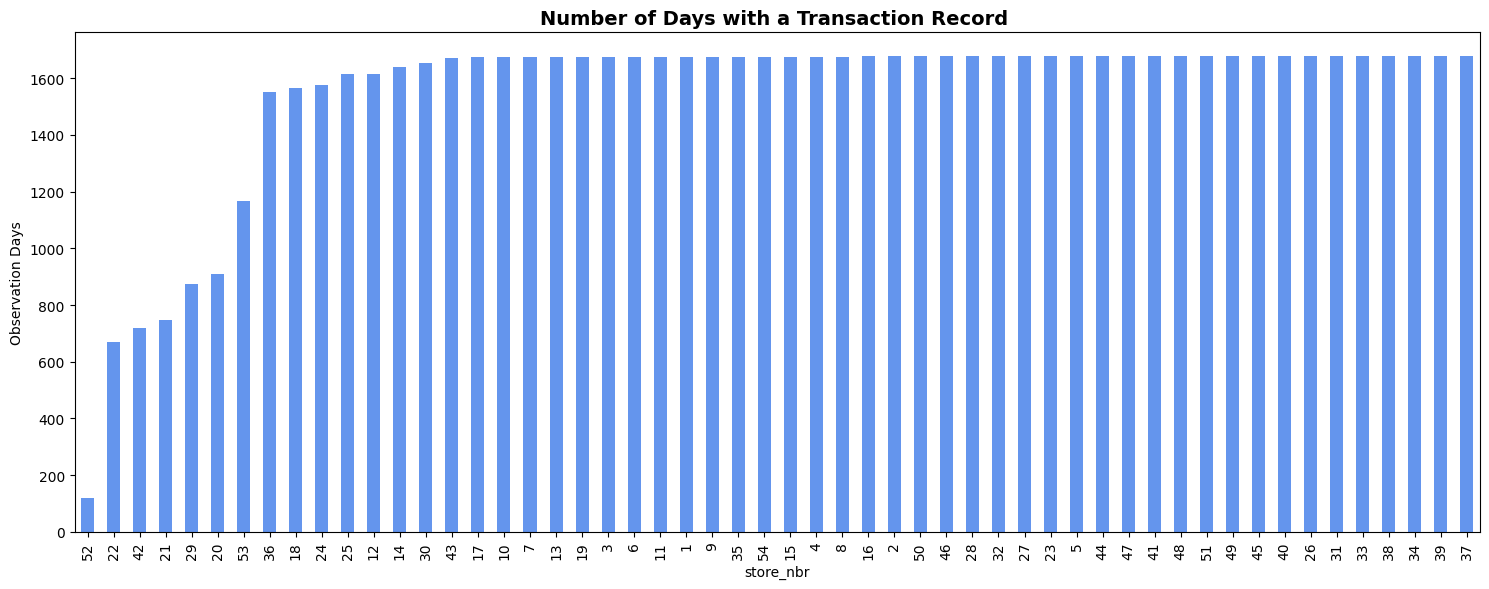

In [5]:
plt.figure(figsize=(15, 6))
days_per_store.plot(kind='bar', color='cornflowerblue')
plt.title('Number of Days with a Transaction Record ', fontsize=14, fontweight='bold')
plt.xlabel('store_nbr')
plt.ylabel('Observation Days')
plt.tight_layout()
plt.show()

### Confirming Late Openings (Structural Zeros)
We inspect the minimum and maximum transaction dates for the stores with the fewest observation days to confirm the late-opening hypothesis (particularly for Store 52, which only has 118 days of transactions). This explains why these stores have a high proportion of zero sales in the training set (structural zeros).

In [6]:
# Check min and max transaction dates for stores with fewer observation days
short_stores = days_per_store.head(10).index
store_dates = transactions[transactions['store_nbr'].isin(short_stores)].groupby('store_nbr')['date'].agg(['min', 'max', 'count'])
store_dates['total_days_in_range'] = (store_dates['max'] - store_dates['min']).dt.days + 1
print("Transaction date ranges for stores with short observation periods:")
print(store_dates.sort_values(by='count'))

Transaction date ranges for stores with short observation periods:
                 min        max  count  total_days_in_range
store_nbr                                                  
52        2017-04-20 2017-08-15    118                  118
22        2015-10-09 2017-08-15    671                  677
42        2015-08-21 2017-08-15    720                  726
21        2015-07-24 2017-08-15    748                  754
29        2015-03-20 2017-08-15    874                  880
20        2015-02-13 2017-08-15    909                  915
53        2014-05-29 2017-08-15   1167                 1175
36        2013-05-09 2017-08-15   1551                 1560
18        2013-01-02 2017-08-15   1566                 1687
24        2013-01-02 2017-08-15   1577                 1687


## 3. Transactions distribution by store

Top 10 stores by average daily transactions:
store_nbr
44    4336.966607
47    3897.322600
45    3697.742993
46    3571.921884
3     3201.879475
48    3045.787120
8     2767.285800
49    2727.550984
50    2614.456768
11    2370.219570
Name: transactions, dtype: float64

Bottom 10 stores by average daily transactions:
store_nbr
10    986.562985
25    941.400619
13    938.248210
16    873.284436
54    865.924821
22    751.350224
30    707.631420
35    670.578162
32    635.197376
26    634.719309
Name: transactions, dtype: float64


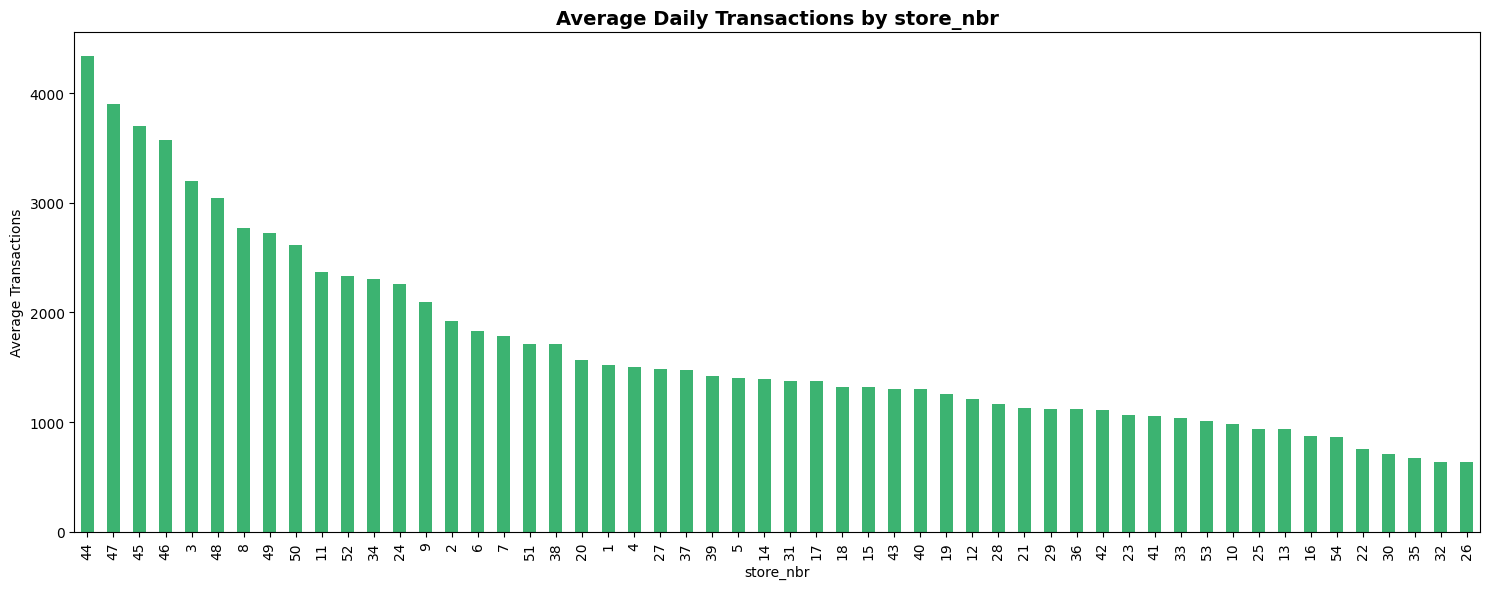

In [7]:
transactions_by_store = transactions.groupby('store_nbr')['transactions'].mean().sort_values(ascending=False)

print("Top 10 stores by average daily transactions:")
print(transactions_by_store.head(10))

print("\nBottom 10 stores by average daily transactions:")
print(transactions_by_store.tail(10))

plt.figure(figsize=(15, 6))
transactions_by_store.plot(kind='bar', color='mediumseagreen')
plt.title('Average Daily Transactions by store_nbr', fontsize=14, fontweight='bold')
plt.xlabel('store_nbr')
plt.ylabel('Average Transactions')
plt.tight_layout()
plt.show()

## 4. Transactions distribution by day of week

Average transactions by day of week:
day_of_week
Monday       1635.556903
Tuesday      1601.308520
Wednesday    1621.497604
Thursday     1549.699882
Friday       1653.989243
Saturday     1952.675786
Sunday       1847.259706
Name: transactions, dtype: float64


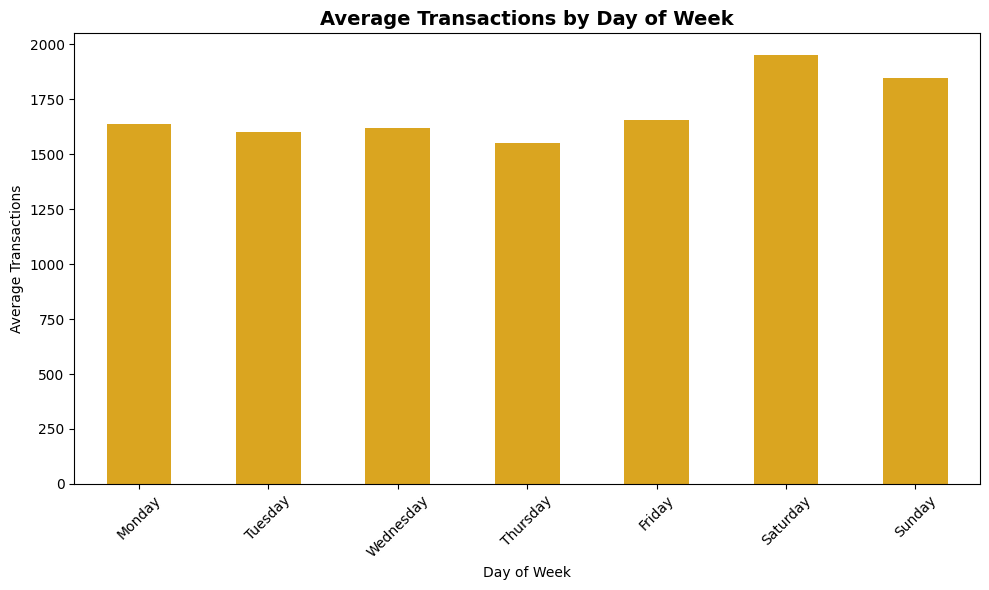

In [8]:
transactions['day_of_week'] = transactions['date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
transactions_by_dow = transactions.groupby('day_of_week')['transactions'].mean().reindex(day_order)

print("Average transactions by day of week:")
print(transactions_by_dow)

plt.figure(figsize=(10, 6))
transactions_by_dow.plot(kind='bar', color='goldenrod')
plt.title('Average Transactions by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()